# AlexNet이 뭐죠?  
CNN을 사용하여 이미지를 보고 어떤 이미지인지 분류하도록 학습 시키는 방법 중 하나  

&nbsp;

준비물 :  
이미지, 참고서, 학습계획, 시험지, 채점자, 몽둥이

---


# 딥러닝 코드 기본 구조

1) 라이브러리
   필요한 도구 불러오기 (import)  
   &nbsp;    

2) 데이터 전처리 계획 → 참고서 및 시험지 만들기  
   이미지를 어떻게 손질할지 정의 (transforms)  
   &nbsp;  

3) 데이터 가져오기 → 참고서 만들 이미지 가져오기  
   데이터셋 로드 (CIFAR10, ImageNet 등)  
   &nbsp;  

4) 데이터 로더 설정
   배치 단위로 나눠서 모델에 전달 (DataLoader)  
   &nbsp;  


=== 데이터 잘 가져왔나 확인 한번 하겠심다!  (plt.show())  ===  
&nbsp;

5) 모델 구조 설계 → 학습 계획
   레이어 정의 (Conv, ReLU, Pool, FC 등)  
   &nbsp;  

6) 학습 방식 설정
   - device (CPU / GPU)  → 공부할 장소(독서실? 도서관?)
   - 손실함수 (CrossEntropyLoss) → 채점자 섭외
   - 옵티마이저 (SGD, Adam) → 몽둥이 주문  
   &nbsp;  

7) 학습 (GAN은 다름)
   순전파 → 손실 계산 → 역전파 → 가중치 업데이트
   (에폭 반복)  
   &nbsp;  

8) 테스트
   model.eval() + torch.no_grad()
   정확도 측정  
   &nbsp;  

9) 시각화
   Loss / Accuracy 그래프

---

1) 라이브러리
   필요한 도구 불러오기 (import)  

In [1]:
# 1. 라이브러리 불러오기
import torch                          # PyTorch 기본 라이브러리
import torch.nn as nn                 # 신경망 레이어들 (Conv, Linear 등)
import torch.optim as optim           # 옵티마이저 (SGD, Adam 등)
import torchvision                    # 이미지 데이터셋, 변환 도구
import torchvision.transforms as transforms # 이미지 전처리용 라이브러리
from torch.utils.data import DataLoader     # 데이터 배치 로딩
from torch.utils.data import Subset         # 데이터 잘라씀(6만장 너무 많아서)

#시각화
import matplotlib.pyplot as plt   # 그래프 그리기
from tqdm import tqdm             # 로딩바

---

2) 데이터 전처리 계획 → 참고서 및 시험지 만들기  
   이미지를 어떻게 손질할지 정의 (transforms)

In [3]:
# 2. 이미지를 전처리 계획(어떻게 손질할지 정의)

# transform 이미지 전처리용 라이브러리
# *Compose* = 어떤 순서대로 전처리 할지 적어놓은 플래너
# 학습용/테스트용 두개가 필요해서 나눠서 객체에 저장

# 학습용엔 데이터 증강을 추가 — 같은 이미지를 매번 다르게 보여줘서 외우는 걸 방지!
train_transform = transforms.Compose([      # 플래너
    transforms.RandomHorizontalFlip(),      # 50% 확률로 좌우 반전 (뒤집어서 보여주기)
    transforms.RandomCrop(32, padding=4),   # 랜덤으로 잘라내기 (살짝 다른 구도로 보여주기)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 밝기/대비를 랜덤하게 변환
    transforms.ToTensor(),      # 이미지 → 텐서 변환 + 픽셀값 0~255 → 0.0~1.0
    transforms.Normalize(       # 0.0~1.0 → -1.0~1.0 (입력값 중심을 0으로 맞춰 기울기 균형)
        mean=(0.5, 0.5, 0.5),   # 0점 조절
        std=(0.5, 0.5, 0.5)     # -1 ~ 1로 범위 조정
    )
])

# 테스트용은 증강 없이 그대로! 시험볼 땐 원본 그대로 평가해야 정확해요
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

---

3) 데이터 가져오기 → 참고서 만들 이미지 가져오기  
   데이터셋 로드 (CIFAR10, ImageNet 등)

1) torchvision 내장 데이터셋 (CIFAR, MNIST 등)  
```
torchvision.datasets.CIFAR10(root='./data', download=True)
```
2) 내 컴퓨터에 있는 이미지 폴더  
```
torchvision.datasets.ImageFolder(root='./my_data')
```
3) CSV 파일  
```
import pandas as pd
df = pd.read_csv('data.csv')
```
4) 직접 커스텀 (가장 유연)  
```
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self): ...
    def __len__(self): ...
    def __getitem__(self, idx): ...
```

In [4]:
# 3. 데이터셋 로드(가져오기)

# CIFAR-10
# 학습용, 테스트용으로 나누고 사용 방법 설정

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',       # 데이터 저장할 폴더
    train=True,          # True = 학습용,
    download=True,       # 없으면 자동으로 다운로드
    transform=train_transform  # 학습용 transform 적용 (증강 있음)
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,         # False = 테스트용
    download=True,
    transform=test_transform   # # 테스트용 transform 적용 (증강 없음)
)

# 총 6만장의 전체 데이터 중 일부만 잘라서 사용 (속도 향상)
train_dataset = Subset(train_dataset, range(10000))  # 학습용 10000장
test_dataset = Subset(test_dataset, range(2000))    # 테스트용 2000장

100%|██████████| 170M/170M [00:04<00:00, 40.9MB/s]


---

4) 데이터 로더 설정
   배치 단위로 나눠서 모델에 전달 (DataLoader)  

In [5]:
# 4. 데이터 로더(배달) 설정

train_loader = DataLoader(
    train_dataset,  # 위에서 만든 학습용 데이터셋
    batch_size=64,  # 한번에 64개씩 전달
    shuffle=True    # 매 epoch마다 순서 섞기(순서 외워서 학습하면 안되니까)
)

test_loader = DataLoader(
    test_dataset,   # 테스트용 데이터셋
    batch_size=64,
    shuffle=False   # 테스트는 섞으면 안됨(결과 비교를 정확히 하기 위해)
)

---

=== 데이터 잘 가져왔나 확인 한번 하고 갈게요!===  
(plt.show())

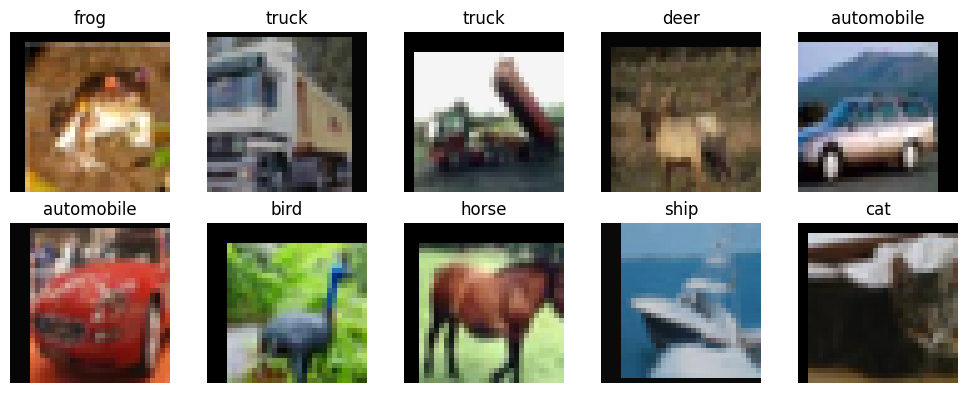

In [6]:
# 데이터 샘플 확인 — 내가 불러온 데이터가 제대로 됐는지 눈으로 확인
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = img * 0.5 + 0.5            # Normalize 역변환 (-1~1 → 0~1) )
    ax.imshow(img.permute(1, 2, 0))  # (C, H, W) → (H, W, C) 로 바꾸기
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

---

5) 모델 구조 설계 → 학습 계획
   레이어 정의 (Conv, ReLU, Pool, FC 등)

    ### 주로 '클래스'로 만듦

#클래스란?
구조와 동작을 하나로 묶어서 재사용할 수 있게 만든 설계도

&nbsp;&nbsp;&nbsp;

nn.Module (최상위 부모)  
    ├── nn.Sequential  ← nn.Module의 자식  
    ├── nn.Conv2d      ← nn.Module의 자식  
    ├── nn.Linear      ← nn.Module의 자식  
    ├── nn.ReLU        ← nn.Module의 자식  
    └── AlexNet        ← 우리가 만든 nn.Module의 자식

    nn.Module 쓰면 되지 뭐하러 또 만드냐?  
    노쇠하심 직접 행동 못하심(기능만 준비되어있음)
    자식이 뜻을 이어 받아서 이뤄 내야함

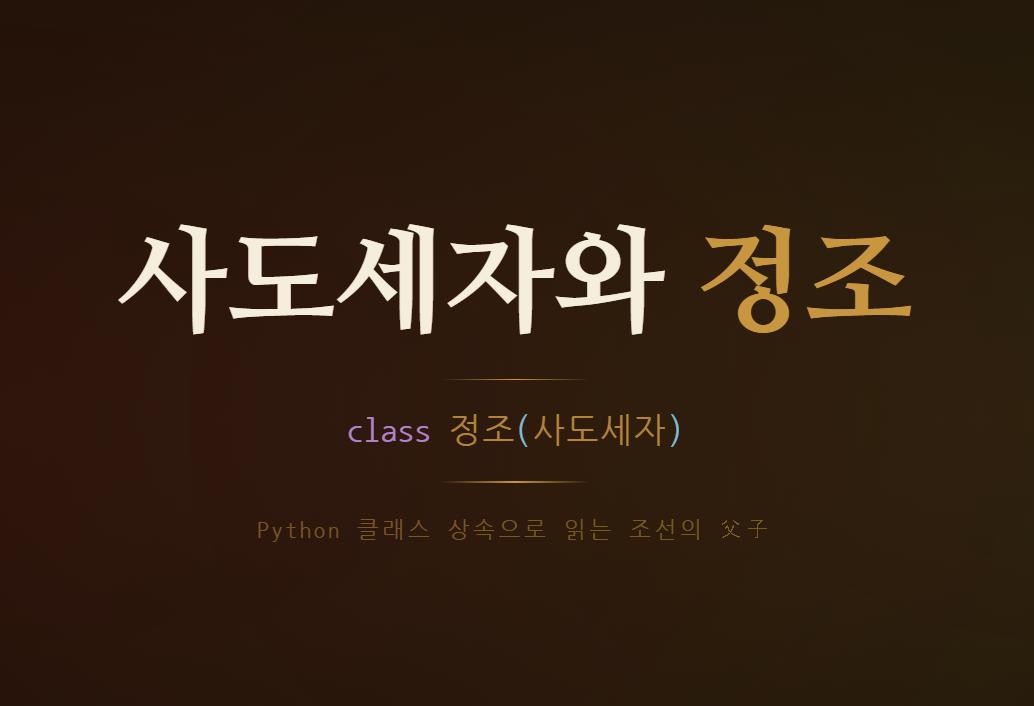

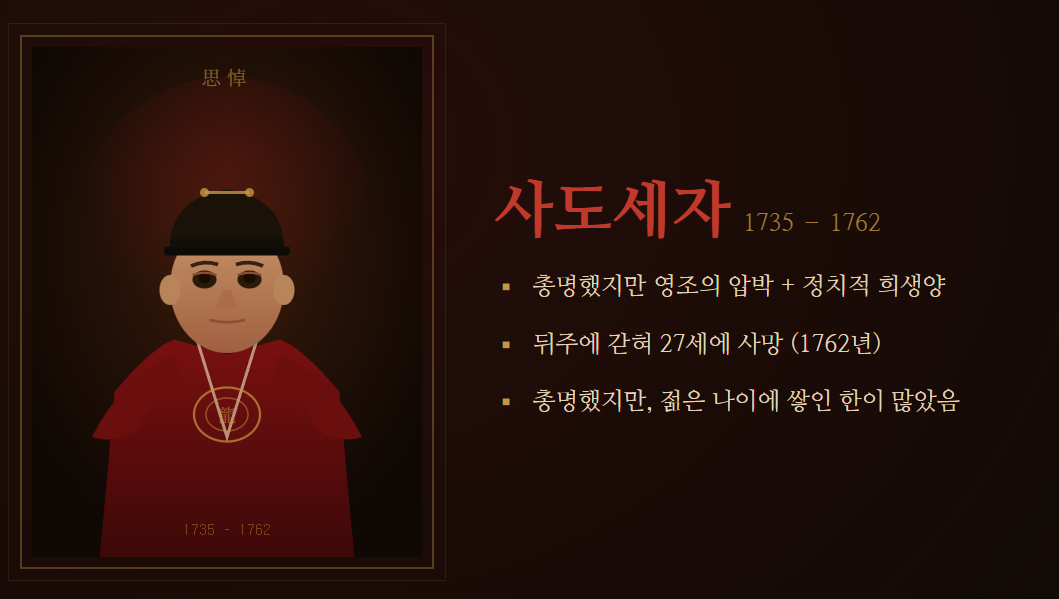

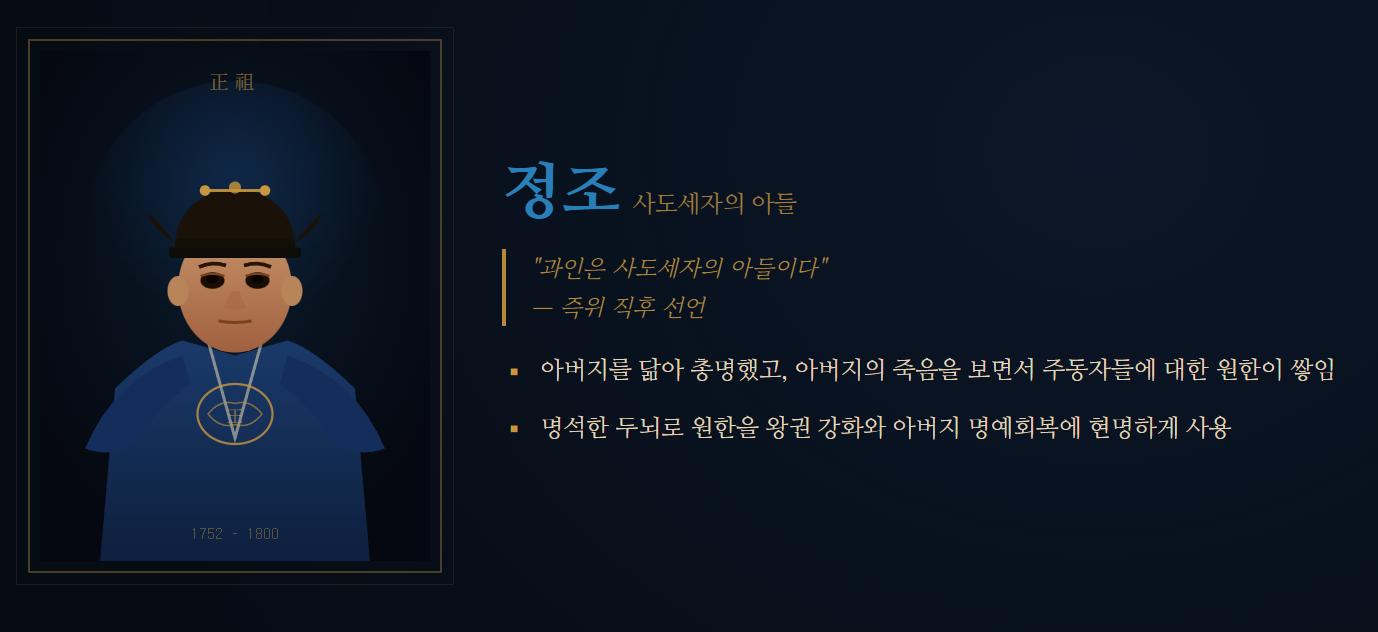

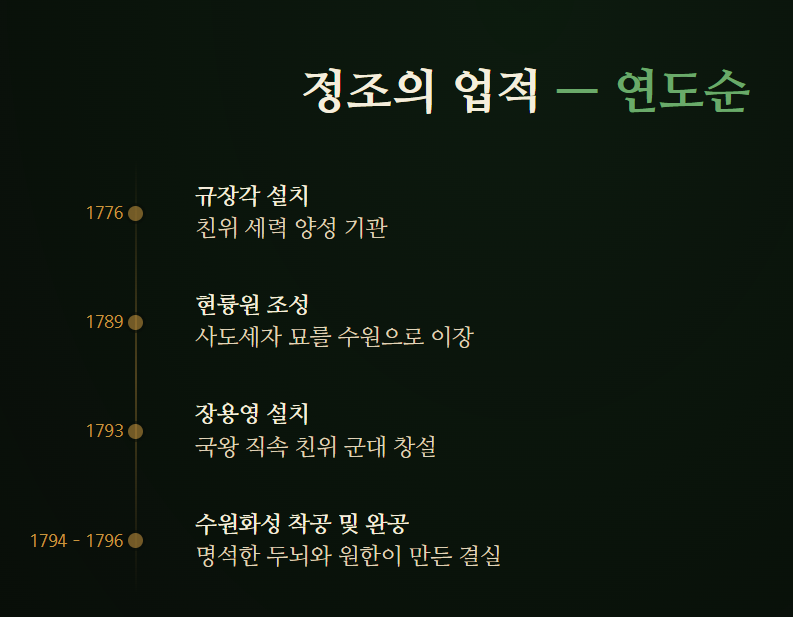

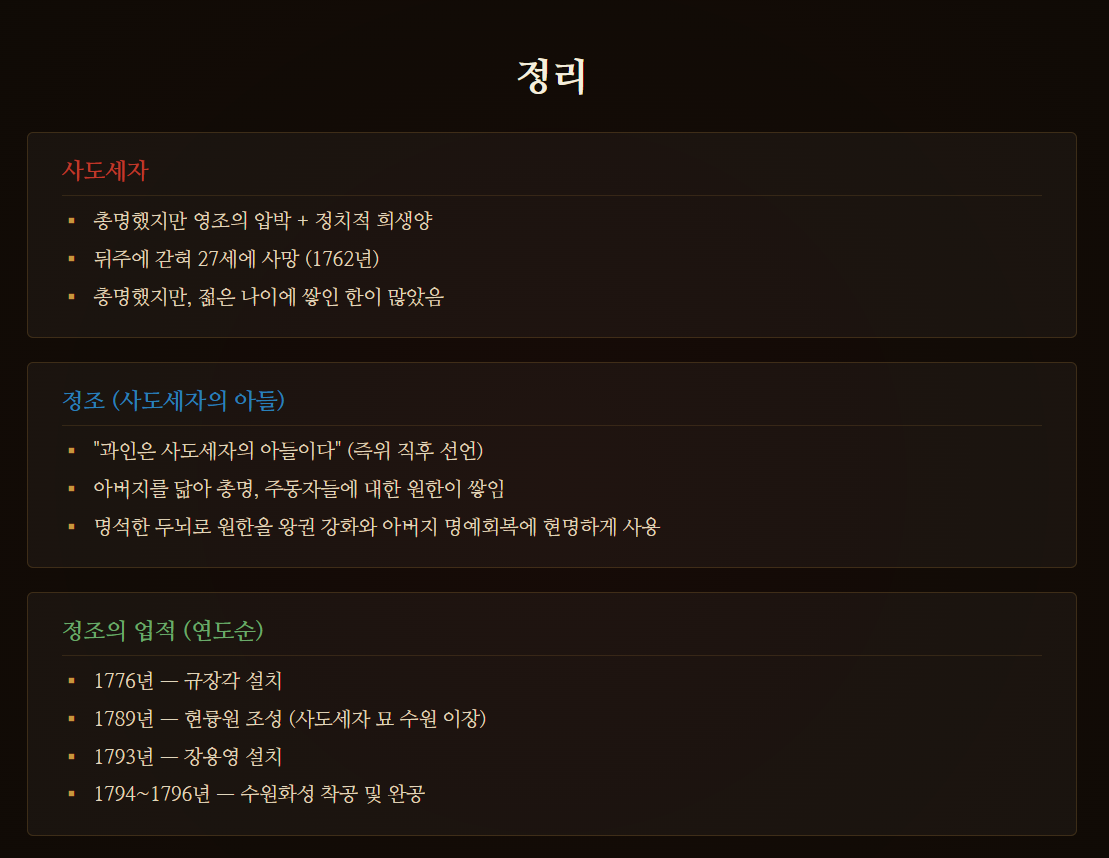

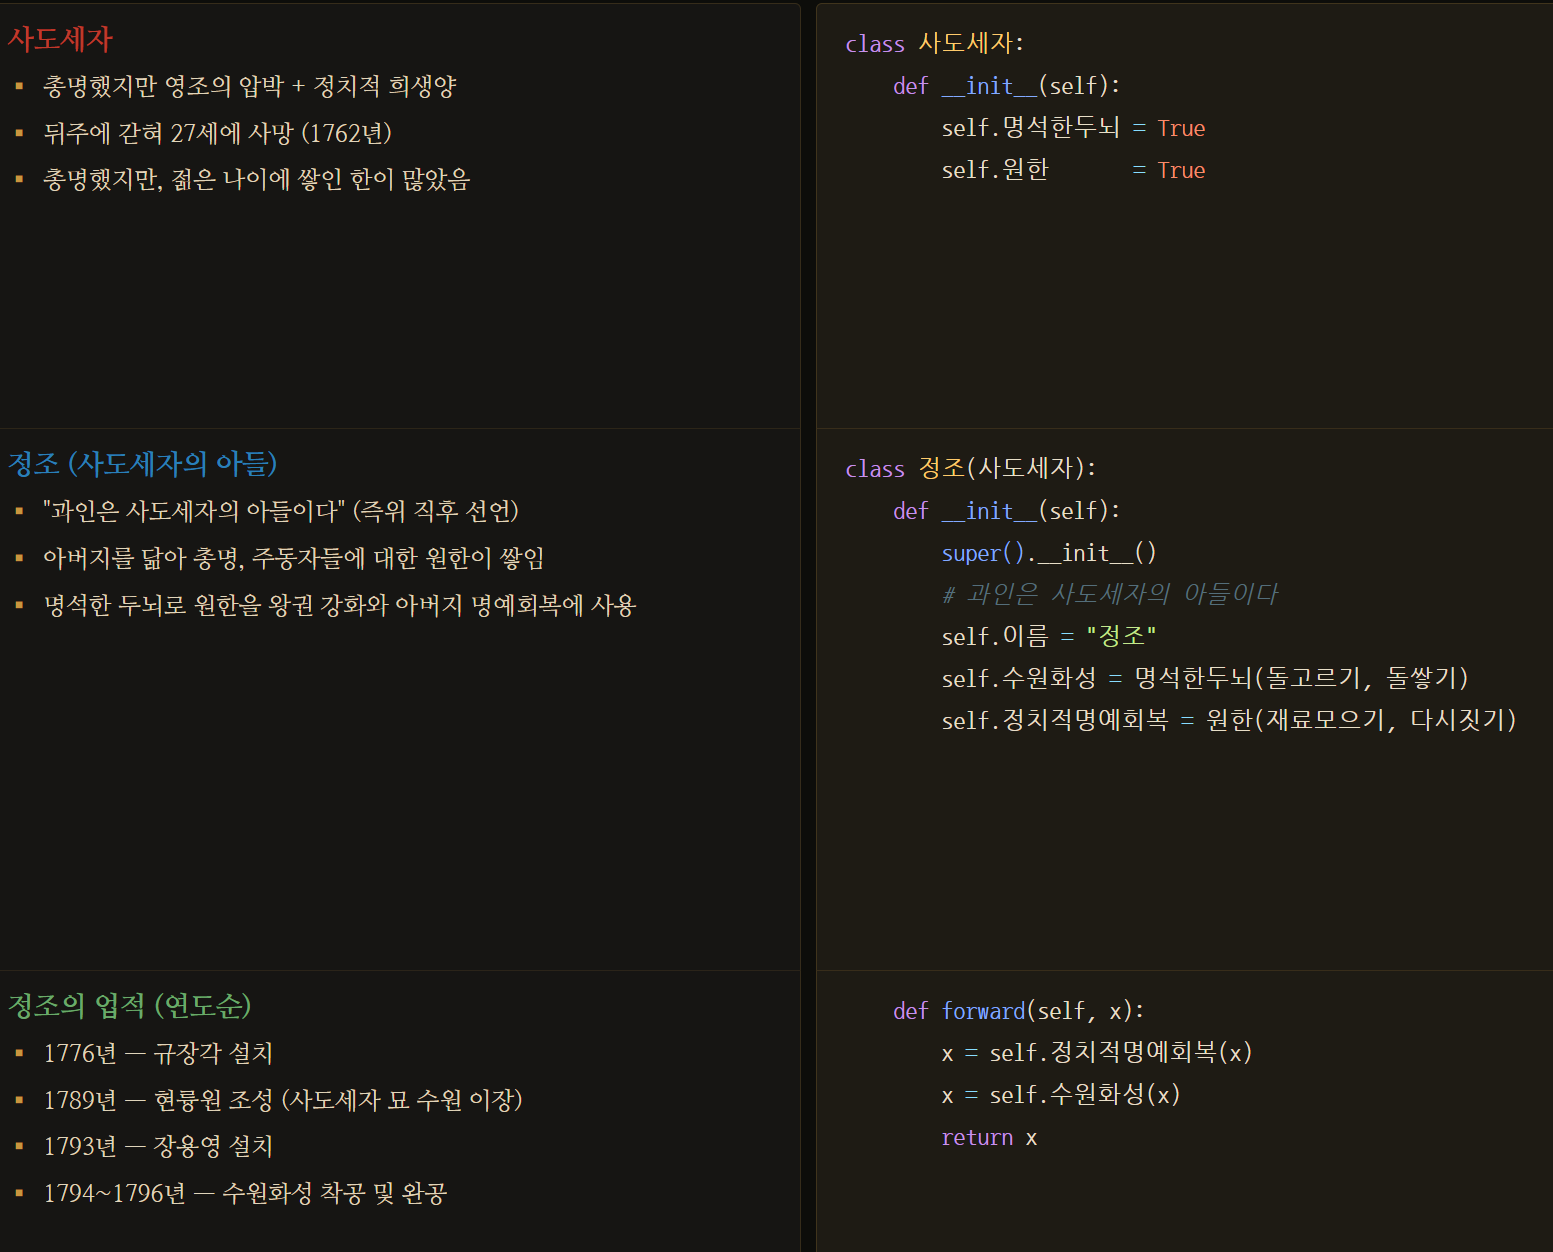

   ---  
&nbsp;
##class AlexNet(nn.Module):  

class 정조(사도세자):

사도세자 (부모클래스 = nn.Module):  
  ✅ 명석한 두뇌  
  ✅ 원한  
&nbsp;  

정조 (자식클래스 = AlexNet):  
  ✅ 명석한 두뇌  ← 사도세자한테 물려받음  
  ✅ 원한&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;← 사도세자한테 물려받음  
  ✅ 조선후기의 성군&nbsp;&nbsp;← 직접 추가  
  ✅ 수원화성 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;       ← 직접 추가

### 그건 현실에서고, 코드상에선 어떻게 가져다 쓰는데???  


코드 예시
```
  super     : 부모한테 물려받기 선언
__init__    : 자식의 정보 및 기능
__forward__ : 그 기능의 발현 순서
```

코드 예시
```
class 사도세자:
    def __init__(self):
        self.명석한두뇌 = True
        self.원한 = True

class 정조(사도세자):
    def __init__(self):
        super().__init__()         # 과인은 사도세자의 아들이다
        self.이름 = "정조"
        self.수원화성 = 명석한두뇌(  # 물려받은 두뇌로 건설
            돌고르기,
            돌쌓기,
        )
        self.정치적명예회복 = 원한(  # 원한으로 무덤 재건
            재료모으기,
            다시짓기,
        )

    def forward(self, x):
        x = self.정치적명예회복(x)
        x = self.수원화성(x)
        return x
```

In [7]:
# 5. 모델 구조 설계

# 주로 클래스로 설정
class AlexNet(nn.Module):
    def __init__(self): # init = 상세 플래너(각 플래너의 상세 내용 기록)
        super().__init__()  # super = 부모 설계도 먼저 불러오기

        # Conv층 — 특징 추출 구역
        self.features = nn.Sequential( # 부모님(nn.S)꺼 받아서 만든 말고 자식의 능력(self.)
                      # nn.Sequential = 특징 뽑는 플래너
                      # sef.features를 입력하면 아래 적어둔 순서대로 플랜을 실행합니다.
            # Conv1 — 큰 특징 감지
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            # R G B(3), 뽑아낼 특징의 수(64), 돋보기의 크기(3x3), 주변에 빈칸(1)칸씩 만들어서 진행
            nn.ReLU(),   # conv가 뽑아낸 특징에서 양수만 골라서 다듬어주는 친구, 오징어다리
            # nn.LocalResponseNorm(size=5, alpha=0.0001, k=2) >> 논문은 여기서 LRN(지역 정규화) 진행
                                                                 #근데 안해도 됨(논문피셜)
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 2x2의 커널 사이즈로 2칸씩 다니면서 Max 값으로 압축

            # Conv2 — 중간 특징 감지
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            # 위에 Conv1에서 받은 64개의 특징을 받아서 진행해 192개의 특징 뽑아내기
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3,4,5 — 세밀한 특징 감지
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            # 위에 Conv2d에게 받은 192개의 특징을 받아서 진행해 384개의 특징 뽑아내기
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 이 사이에 1열로 쭉 펴는 단계가 있음(실제 코드는 foward에)

        # FC층 — 최종 판단!
        # self.classifier에서의 nn.Sequential = 판단 플래너
        # self.classifier 을 입력하면 아래 적어둔 순서대로 판단 플랜을 시작
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                 # 과적합 방지 (0.5 = 절반의 뉴런을 랜덤으로 끄기)
            nn.Linear(256 * 4 * 4, 4096),    # FC1 (쉽게 지방법원)
            # 리니어에서 256 * 4 * 4 라고 표현하는 이유는, 어디서 왔는지 알아보기 쉬우려고
            nn.ReLU(),                       # 의미 없는 판단을 0으로
            nn.Dropout(0.5),                 # 0.5 명시 (기본값이지만 명확하게 적기)
            nn.Linear(4096, 4096),           # FC2 (고등법원)
            nn.ReLU(),
            nn.Linear(4096, 10),             # FC3 (대법원) — 최종 10개 분류
        )

    def forward(self, x):             # 플래너 읽는 순서(데이터가 들어오면 이 대로 통과해!)
        x = self.features(x)          # 특징 추출 플래너 순서대로 진행
        x = x.view(x.size(0), -1)     # 1열로 쫙 펼쳐서
        x = self.classifier(x)        # 판단 플래너에 넣고 순서대로 진행
        return x

###논문 코드 구현 시각화  
1. 사진 한장을 양쪽의 gpu로 보냄  
2. conv1 과 conv2를 통과하면서 각각 48 >> 128개의 커널 출력(총 256채널)  
  
3. 두 gpu 결과물 모아서 conv3에 투입(정보 공유) 및 384개의 커널 출력
  
4. 다시 두 gpu로 나눠 conv4, conv5에 투입 커널은 conv4에선 384개 그대로, conv 5에선 256(각각 128)개로 감소
  
### 총 256채널짜리 데이터가 다시 만나서 FC1으로 들어감


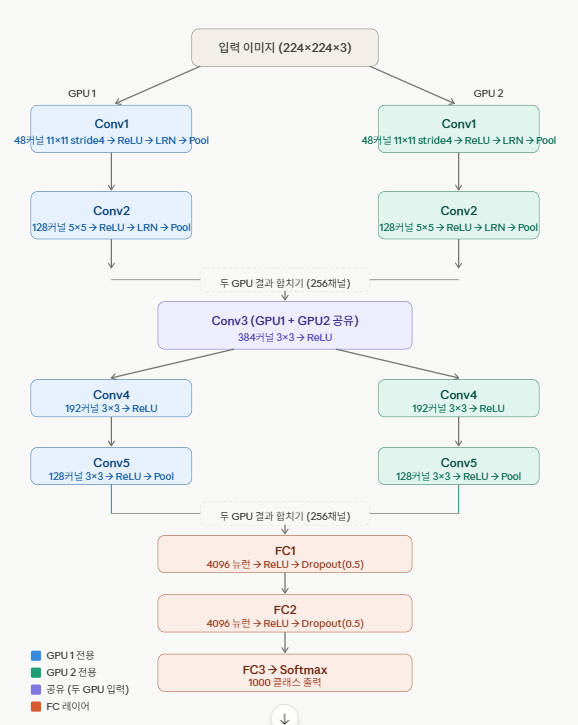

---

6) 학습 방식 설정
   - device (CPU / GPU)  → 공부할 장소(독서실? 도서관?)
   - 손실함수 (CrossEntropyLoss) → 채점자 섭외
   - 옵티마이저 (SGD, Adam)      → 몽둥이 주문

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용중인 장치: {device}")  # 확인용

model = AlexNet().to(device)  # 모델을 더 빨리 배울 수 있는 GPU로 이동!

# 1. 손실함수 — 얼마나 틀렸는지 측정(채점관)
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss라는 채점관을 데려와서 얼마나 틀렸는지 측정하게함


# 2. 옵티마이저 — 오차를 줄이는 방향으로 가중치 업데이트
optimizer = optim.SGD(   # SGD라는 수리공을 데려와서 'optimizer'라는 객체 생성
    model.parameters(),  # 업데이트할 가중치 목록(conv, linear...) 전달
    lr=0.01,             # 얼마나 고칠지
    momentum=0.9,        # 관성을 얼마나 줄지
    weight_decay=1e-4    # 가중치 크기 제한 (과적합 방지) 오징어다리
)

사용중인 장치: cuda


---

7) 학습 (GAN은 다름)
   순전파 → 손실 계산 → 역전파 → 가중치 업데이트
   (에폭 반복)  

   (model.train())  

8) 테스트(Loss, accuracy 따로 측정)  
model.eval() + torch.no_grad()  


In [9]:
#학습 기록용 리스트(그래프를 그리기 위함)
loss_list = []       # 손실값 기록
val_loss_list = []   # val loss 기록

for epoch in range(20):                  # 전체 데이터 10번 반복

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/20"):
        # 🚚 배달부가 64장씩 배달(사진, 라벨)
        # train_loader 데이터는 사진과 라벨(1 ~ 10까지)로 되어있음
        # 학습시킬땐 사진 보여주고 이건 1이야, 이건 3이야 이런식으로 학습을 해야함
        # 그래서 for문을 통해 차례대로 이미지와 라벨을 꺼냄

        images = images.to(device)  # 이미지를 GPU로 이동
        labels = labels.to(device)  # 라벨을 GPU로 이동

        # 1. 이전 계산 초기화
        optimizer.zero_grad()

        # 2. 🗺️ forward — 예측하기
        outputs = model(images)
        # 여기서 model = 알렉스넷() 한테 image를 넣으면 Pythorch가 자동으로 forward를 실행

        # 3. 📝 손실 계산 — 얼마나 틀렸어?
        # 모델이 예측한 10개 클래스에 대한 확률과 실제 정답(라벨)을 비교
        loss = criterion(outputs, labels)

        # 4. ↩️ backward — 어디서 틀렸는지 추적(역전파)
        loss.backward()

        # 5. 🔧 가중치 수정
        # 이 step을 적어야 수리공이 직접 가서 고침, 빼먹으면 수리 안하고 넘어감
        # 실제 업데이트가 일어나는
        optimizer.step()
        train_loss += loss.item()
    loss_list.append(train_loss / len(train_loader))  # 배치 평균으로 저장

    # Loss 측정
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss_v = criterion(outputs, labels)  # val loss 계산
            val_loss += loss_v.item()

    val_loss_list.append(val_loss / len(test_loader))  # 평균 val loss 저장

    print(f"{epoch+1}번째 완료! train loss: {loss:.4f} | val loss: {val_loss/len(test_loader):.4f}")

Epoch 1/20: 100%|██████████| 157/157 [00:12<00:00, 12.18it/s]


1번째 완료! train loss: 2.2985 | val loss: 2.3016


Epoch 2/20: 100%|██████████| 157/157 [00:11<00:00, 13.36it/s]


2번째 완료! train loss: 2.3176 | val loss: 2.2960


Epoch 3/20: 100%|██████████| 157/157 [00:12<00:00, 13.03it/s]


...

18번째 완료! train loss: 1.3178 | val loss: 1.0878


Epoch 19/20: 100%|██████████| 157/157 [00:11<00:00, 13.71it/s]


19번째 완료! train loss: 0.7225 | val loss: 1.0668


Epoch 20/20: 100%|██████████| 157/157 [00:11<00:00, 13.58it/s]


20번째 완료! train loss: 0.9064 | val loss: 1.0641


---

8) accuracy 측정  
   model.eval() + torch.no_grad()
   정확도 측정

In [10]:
# 테스트 하는 곳!(몇개 맞췄는지  정확도 값을 구함)
accuracy_list = []   # 정확도 기록

correct = 0  # 맞춘 개수 업데이트용 변수
total = 0    # 전체 개수 업데이트용 변수
model.eval() # 평가 모드 - Dropout 끄기 (모든 뉴런 다 켜기, 오징어다리 풀 가동)
# 시험볼 땐 오답노트 적을 필요 없음>> 빨리 빨리 계산하고 넘어가야하기에
with torch.no_grad():
# 👆 'with'는 내부 룰 선언임
# "이 안에서는 gradient 계산 끄고
#  평가만 할거야!"
    for images, labels in test_loader:  # 테스트 로더의 이미지와 라벨들을
        images = images.to(device)      # (이미지를 GPU로 이동)
        labels = labels.to(device)      # (라벨을 GPU로 이동)
        outputs = model(images)         #  훈련시킨 모델에 넣고 예측한 값을 outputs에 저장
        _, predicted = torch.max(outputs, 1) # outputs값을, 1번축(열방향) 방향으로 보면서
                                             # max 값(가장 높은 확률의 예측값)을 predicted에 저장
        total += labels.size(0)                 # 전체 개수 누적
        correct += (predicted == labels).sum()  # 맞춘 개수 누적
    accuracy = 100 * correct.cpu() / total
    # 맞춘 개수 / 전체 개수 * 100
    # = 퍼센트로 변환! >> 시각화용 코드
    print(f"최종 정확도: {accuracy:.2f}%")

최종 정확도: 62.40%


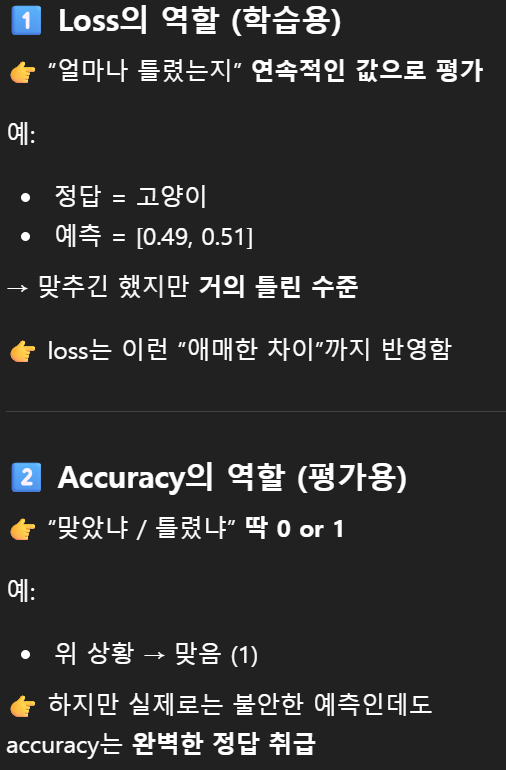

/tmp/ipykernel_651/646943155.py:10: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_651/646943155.py:10: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_651/646943155.py:10: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_651/646943155.py:10: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist

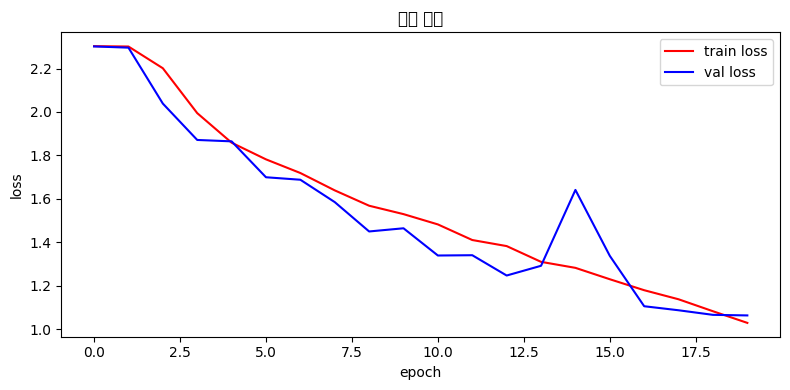

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(loss_list, color='red', label='train loss')
ax.plot(val_loss_list, color='blue', label='val loss')
ax.set_title('학습 진행')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()  # 범례 표시

plt.tight_layout()
plt.show()